# Geometry of Truth Dataset — Exploratory Data Analysis

This notebook explores the Geometry of Truth dataset for use in the SAE-Faithful project. The goal is to inspect the dataset structure, understand the true/false statement labels, assess data quality, and prepare the dataset for later concept-detection and causal-faithfulness experiments.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/saprmarks/geometry-of-truth/main/datasets/cities.csv"

cities = pd.read_csv(url)

cities.head()

,statement,label,city,country,correct_country
0,The city of Krasnodar is in Russia.,1,Krasnodar,Russia,Russia
1,The city of Krasnodar is in South Africa.,0,Krasnodar,South Africa,Russia
2,The city of Lodz is in Poland.,1,Lodz,Poland,Poland
3,The city of Lodz is in the Dominican Republic.,0,Lodz,the Dominican Republic,Poland
4,The city of Maracay is in Venezuela.,1,Maracay,Venezuela,Venezuela


In [6]:
print("Shape:", cities.shape)

print("\nColumns:")
print(cities.columns.tolist())

print("\nData types:")
print(cities.dtypes)

print("\nMissing values:")
print(cities.isnull().sum())

print("\nLabel distribution:")
print(cities["label"].value_counts())

print("\nLabel proportions:")
print(cities["label"].value_counts(normalize=True))

Shape: (1496, 5)

Columns:
['statement', 'label', 'city', 'country', 'correct_country']

Data types:
statement          object
label               int64
city               object
country            object
correct_country    object
dtype: object

Missing values:
statement          0
label              0
city               0
country            0
correct_country    0
dtype: int64

Label distribution:
label
1    748
0    748
Name: count, dtype: int64

Label proportions:
label
1    0.5
0    0.5
Name: proportion, dtype: float64


In [7]:
# Text length analysis
cities["char_length"] = cities["statement"].str.len()
cities["word_count"] = cities["statement"].str.split().str.len()

print("Character length summary:")
print(cities["char_length"].describe())

print("\nWord count summary:")
print(cities["word_count"].describe())

print("\nAverage word count by label:")
print(cities.groupby("label")["word_count"].mean())

Character length summary:
count    1496.000000
mean       35.272727
std         5.210789
min        27.000000
25%        32.000000
50%        34.000000
75%        37.000000
max        71.000000
Name: char_length, dtype: float64

Word count summary:
count    1496.000000
mean        7.375000
std         0.823007
min         7.000000
25%         7.000000
50%         7.000000
75%         7.000000
max        14.000000
Name: word_count, dtype: float64

Average word count by label:
label
0    7.386364
1    7.363636
Name: word_count, dtype: float64


In [8]:
print("Duplicate rows:", cities.duplicated().sum())
print("Duplicate statements:", cities["statement"].duplicated().sum())

print("\nUnique cities:", cities["city"].nunique())
print("Unique stated countries:", cities["country"].nunique())
print("Unique correct countries:", cities["correct_country"].nunique())

Duplicate rows: 0
Duplicate statements: 0

Unique cities: 748
Unique stated countries: 108
Unique correct countries: 108


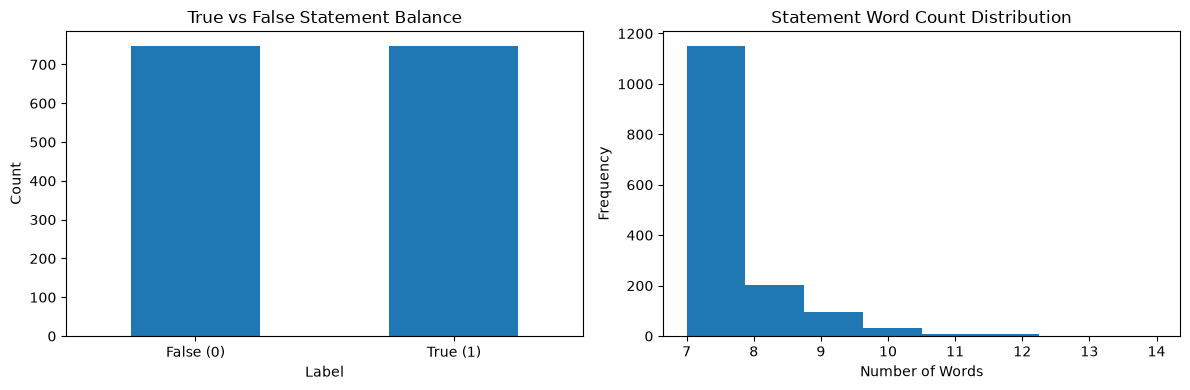

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Label balance
cities["label"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("True vs False Statement Balance")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["False (0)", "True (1)"], rotation=0)

# Word count distribution
cities["word_count"].plot(
    kind="hist",
    bins=8,
    ax=axes[1]
)
axes[1].set_title("Statement Word Count Distribution")
axes[1].set_xlabel("Number of Words")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

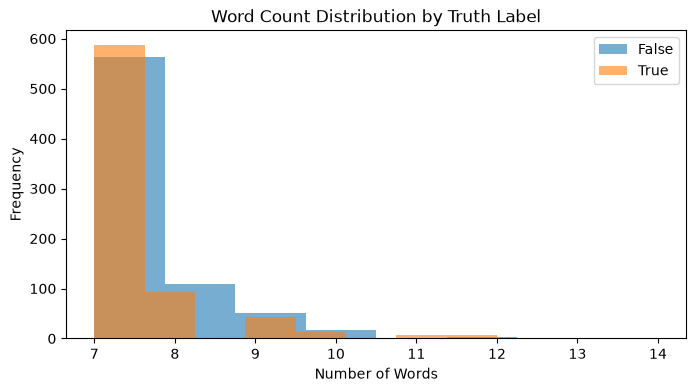

In [10]:
plt.figure(figsize=(8, 4))

cities[cities["label"] == 0]["word_count"].plot(
    kind="hist",
    bins=8,
    alpha=0.6,
    label="False"
)

cities[cities["label"] == 1]["word_count"].plot(
    kind="hist",
    bins=8,
    alpha=0.6,
    label="True"
)

plt.title("Word Count Distribution by Truth Label")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [11]:
false_examples = cities[cities["label"] == 0].head(10)
true_examples = cities[cities["label"] == 1].head(10)

print("True examples:")
display(true_examples[["statement", "city", "country", "correct_country"]])

print("\nFalse examples:")
display(false_examples[["statement", "city", "country", "correct_country"]])

True examples:


,statement,city,country,correct_country
0,The city of Krasnodar is in Russia.,Krasnodar,Russia,Russia
2,The city of Lodz is in Poland.,Lodz,Poland,Poland
4,The city of Maracay is in Venezuela.,Maracay,Venezuela,Venezuela
6,The city of Baku is in Azerbaijan.,Baku,Azerbaijan,Azerbaijan
8,The city of Baoji is in China.,Baoji,China,China
10,The city of Addis Ababa is in Ethiopia.,Addis Ababa,Ethiopia,Ethiopia
12,The city of Abidjan is in Côte d'Ivoire.,Abidjan,Côte d'Ivoire,Côte d'Ivoire
14,The city of Yongzhou is in China.,Yongzhou,China,China
16,The city of Nanchong is in China.,Nanchong,China,China
18,The city of Lu'an is in China.,Lu'an,China,China



False examples:


,statement,city,country,correct_country
1,The city of Krasnodar is in South Africa.,Krasnodar,South Africa,Russia
3,The city of Lodz is in the Dominican Republic.,Lodz,the Dominican Republic,Poland
5,The city of Maracay is in China.,Maracay,China,Venezuela
7,The city of Baku is in Ukraine.,Baku,Ukraine,Azerbaijan
9,The city of Baoji is in Guatemala.,Baoji,Guatemala,China
11,The city of Addis Ababa is in Indonesia.,Addis Ababa,Indonesia,Ethiopia
13,The city of Abidjan is in China.,Abidjan,China,Côte d'Ivoire
15,The city of Yongzhou is in Ukraine.,Yongzhou,Ukraine,China
17,The city of Nanchong is in Nigeria.,Nanchong,Nigeria,China
19,The city of Lu'an is in Turkey.,Lu'an,Turkey,China


In [12]:
city_counts = cities.groupby("city").size()

print("Statements per city:")
print(city_counts.value_counts().sort_index())

paired_check = cities.groupby("city")["label"].nunique()

print("\nCities with both true and false labels:")
print((paired_check == 2).sum())

print("Total unique cities:")
print(cities["city"].nunique())

Statements per city:
2    748
Name: count, dtype: int64

Cities with both true and false labels:
748
Total unique cities:
748


Top 15 correct countries by number of cities:
correct_country
China                384
India                170
Russia                70
Brazil                68
Mexico                46
Indonesia             42
Japan                 42
Turkey                38
South Korea           36
Nigeria               36
Pakistan              30
Iran                  26
the United States     26
Malaysia              24
Iraq                  22
Name: count, dtype: int64


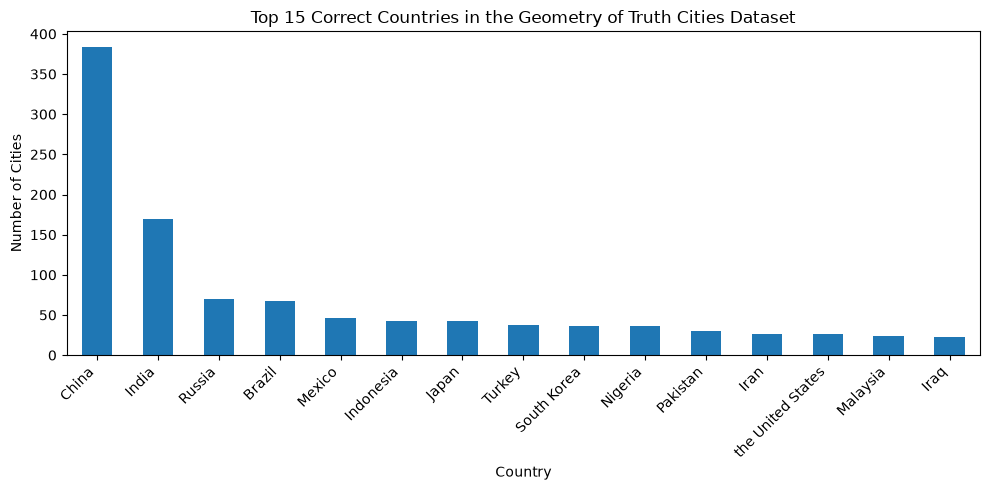

In [13]:
top_correct_countries = cities["correct_country"].value_counts().head(15)

print("Top 15 correct countries by number of cities:")
print(top_correct_countries)

plt.figure(figsize=(10, 5))
top_correct_countries.plot(kind="bar")
plt.title("Top 15 Correct Countries in the Geometry of Truth Cities Dataset")
plt.xlabel("Country")
plt.ylabel("Number of Cities")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [14]:
country_counts = cities["correct_country"].value_counts()

top_2_share = country_counts.head(2).sum() / country_counts.sum()
top_5_share = country_counts.head(5).sum() / country_counts.sum()

print(f"Share of cities from top 2 countries: {top_2_share:.2%}")
print(f"Share of cities from top 5 countries: {top_5_share:.2%}")

Share of cities from top 2 countries: 37.03%
Share of cities from top 5 countries: 49.33%


In [16]:

summary = pd.DataFrame({
    "metric": [
        "rows",
        "original_columns",
        "derived_text_features",
        "missing_values",
        "duplicate_rows",
        "duplicate_statements",
        "true_statements",
        "false_statements",
        "unique_cities",
        "unique_correct_countries",
        "mean_word_count",
        "top_2_country_share",
        "top_5_country_share"
    ],
    "value": [
        len(cities),
        5,
        2,
        cities.isnull().sum().sum(),
        cities.duplicated().sum(),
        cities["statement"].duplicated().sum(),
        (cities["label"] == 1).sum(),
        (cities["label"] == 0).sum(),
        cities["city"].nunique(),
        cities["correct_country"].nunique(),
        cities["word_count"].mean(),
        top_2_share,
        top_5_share
    ]
})

summary

,metric,value
0,rows,1496.000000
1,original_columns,5.000000
2,derived_text_features,2.000000
3,missing_values,0.000000
4,duplicate_rows,0.000000
5,duplicate_statements,0.000000
6,true_statements,748.000000
7,false_statements,748.000000
8,unique_cities,748.000000
9,unique_correct_countries,108.000000


In [18]:
summary.to_csv("../results/geometry_of_truth_eda_summary.csv", index=False)